In [1]:
import duckdb
import pandas as pd

# connect to our database
con = duckdb.connect(
    "/Users/luislimon/Apple-Project/appl-catalyst-intelligence/appl_catalyst.duckdb",
    read_only=True
)

# Step 1 — load daily prices sorted oldest to newest
df = con.execute("""
    SELECT Date, Close
    FROM silver_price_daily
    WHERE ticker = 'AAPL'
    ORDER BY Date ASC
""").df()

print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
df.head()

Rows: 576
Date range: 2024-05-02 00:00:00 → 2026-08-19 00:00:00


,Date,Close
0,2024-05-02,171.470001
1,2024-05-03,181.729996
2,2024-05-06,180.070007
3,2024-05-07,180.750000
4,2024-05-08,181.089996


In [2]:
# Step 2 — sort by date and calculate daily returns
df = df.sort_values("Date").reset_index(drop=True)

# pct_change() divides today's close by yesterday's close and subtracts 1
# e.g. (185 - 184) / 184 = 0.0054 = 0.54% return
df["return"] = df["Close"].pct_change()

# drop the first row — it has no return (no previous day to compare to)
df = df.dropna(subset=["return"]).reset_index(drop=True)

print(f"Total trading days: {len(df)}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
df[["Date", "Close", "return"]].head()

Total trading days: 575
Date range: 2024-05-03 00:00:00 → 2026-08-19 00:00:00


,Date,Close,return
0,2024-05-03,181.729996,0.059836
1,2024-05-06,180.070007,-0.009134
2,2024-05-07,180.750000,0.003776
3,2024-05-08,181.089996,0.001881
4,2024-05-09,182.910004,0.010050


In [3]:
# Step 3 — choose a rolling window of 60 trading days
window = 60

# for each 60-day period, calculate:
# - mean return
# - standard deviation
# - excess kurtosis (how fat the tails are vs normal)
# - skewness (how lopsided the distribution is)

df["roll_mean"]     = df["return"].rolling(window).mean()
df["roll_std"]      = df["return"].rolling(window).std()
df["roll_kurtosis"] = df["return"].rolling(window).kurt()
df["roll_skew"]     = df["return"].rolling(window).skew()

# first 59 rows will be NaN — not enough history yet for a full 60-day window
df_roll = df.dropna().reset_index(drop=True)

print(f"Rolling windows calculated: {len(df_roll)}")
df_roll[["Date", "roll_mean", "roll_std", "roll_kurtosis", "roll_skew"]].head()

Rolling windows calculated: 516


,Date,roll_mean,roll_std,roll_kurtosis,roll_skew
0,2024-07-30,0.004073,0.017409,4.449178,1.287141
1,2024-07-31,0.003325,0.015869,5.209779,1.090711
2,2024-08-01,0.003198,0.016001,5.013504,1.062297
3,2024-08-02,0.003250,0.016008,4.984796,1.051093
4,2024-08-05,0.002416,0.017330,4.316097,0.519854


In [7]:
import numpy as np

def count_extremes(series):
    mean = series.mean()
    std  = series.std()
    return (np.abs(series - mean) > 2 * std).sum()

df["extreme_count"] = df["return"].rolling(window).apply(count_extremes, raw=True)
df["extreme_freq"]  = df["extreme_count"] / window

df_roll = df.dropna().reset_index(drop=True)

print(f"Average extreme days per 60-day window: {df_roll['extreme_count'].mean():.1f}")
print(f"Average extreme frequency: {df_roll['extreme_freq'].mean():.1%}")
df_roll[["Date", "extreme_count", "extreme_freq"]].head()

Average extreme days per 60-day window: 3.6
Average extreme frequency: 6.1%


,Date,extreme_count,extreme_freq
0,2024-07-30,2.0,0.033333
1,2024-07-31,2.0,0.033333
2,2024-08-01,2.0,0.033333
3,2024-08-02,2.0,0.033333
4,2024-08-05,2.0,0.033333


In [8]:
from scipy import stats

# Step 5 — Jarque-Bera normality test on each 60-day window
# JB tests whether skewness and kurtosis match a normal distribution
# p-value < 0.05 = returns in this window are NOT normally distributed

jb_pvalues = []

for i in range(len(df)):
    if i < window - 1:
        jb_pvalues.append(None)   # not enough data yet
    else:
        window_returns = df["return"].iloc[i - window + 1 : i + 1]
        _, p = stats.jarque_bera(window_returns)
        jb_pvalues.append(p)

df["jb_pvalue"] = jb_pvalues

df_roll = df.dropna().reset_index(drop=True)

print(f"Windows where returns are NOT normal (p < 0.05): {(df_roll['jb_pvalue'] < 0.05).sum()}")
print(f"Out of total windows: {len(df_roll)}")
df_roll[["Date", "roll_kurtosis", "jb_pvalue"]].head()

Windows where returns are NOT normal (p < 0.05): 343
Out of total windows: 516


,Date,roll_kurtosis,jb_pvalue
0,2024-07-30,4.449178,8.807457e-13
1,2024-07-31,5.209779,4.149497e-15
2,2024-08-01,5.013504,4.406959e-14
3,2024-08-02,4.984796,6.632320e-14
4,2024-08-05,4.316097,2.124034e-09


In [9]:
# filter to the last 60 days only
last_60 = df_roll.tail(60).reset_index(drop=True)

print(f"Date range: {last_60['Date'].min()} → {last_60['Date'].max()}")
print(f"Avg kurtosis:       {last_60['roll_kurtosis'].mean():.2f}")
print(f"Avg extreme freq:   {last_60['extreme_freq'].mean():.1%}")
print(f"Not-normal windows: {(last_60['jb_pvalue'] < 0.05).sum()} / {len(last_60)}")

last_60[["Date", "roll_kurtosis", "jb_pvalue", "extreme_freq"]].tail(10)

Date range: 2026-05-26 00:00:00 → 2026-08-19 00:00:00
Avg kurtosis:       1.71
Avg extreme freq:   4.7%
Not-normal windows: 39 / 60


,Date,roll_kurtosis,jb_pvalue,extreme_freq
50,2026-08-06,3.575863,2.578744e-08,0.05
51,2026-08-07,3.578976,2.732319e-08,0.05
52,2026-08-10,3.429293,1.470324e-07,0.05
53,2026-08-11,3.336464,3.498053e-07,0.05
54,2026-08-12,3.265641,7.860988e-07,0.05
55,2026-08-13,3.311713,4.072985e-07,0.05
56,2026-08-14,3.310668,4.230050e-07,0.05
57,2026-08-17,3.328487,4.533140e-07,0.05
58,2026-08-18,3.283455,6.005461e-07,0.05
59,2026-08-19,3.170139,1.368911e-06,0.05


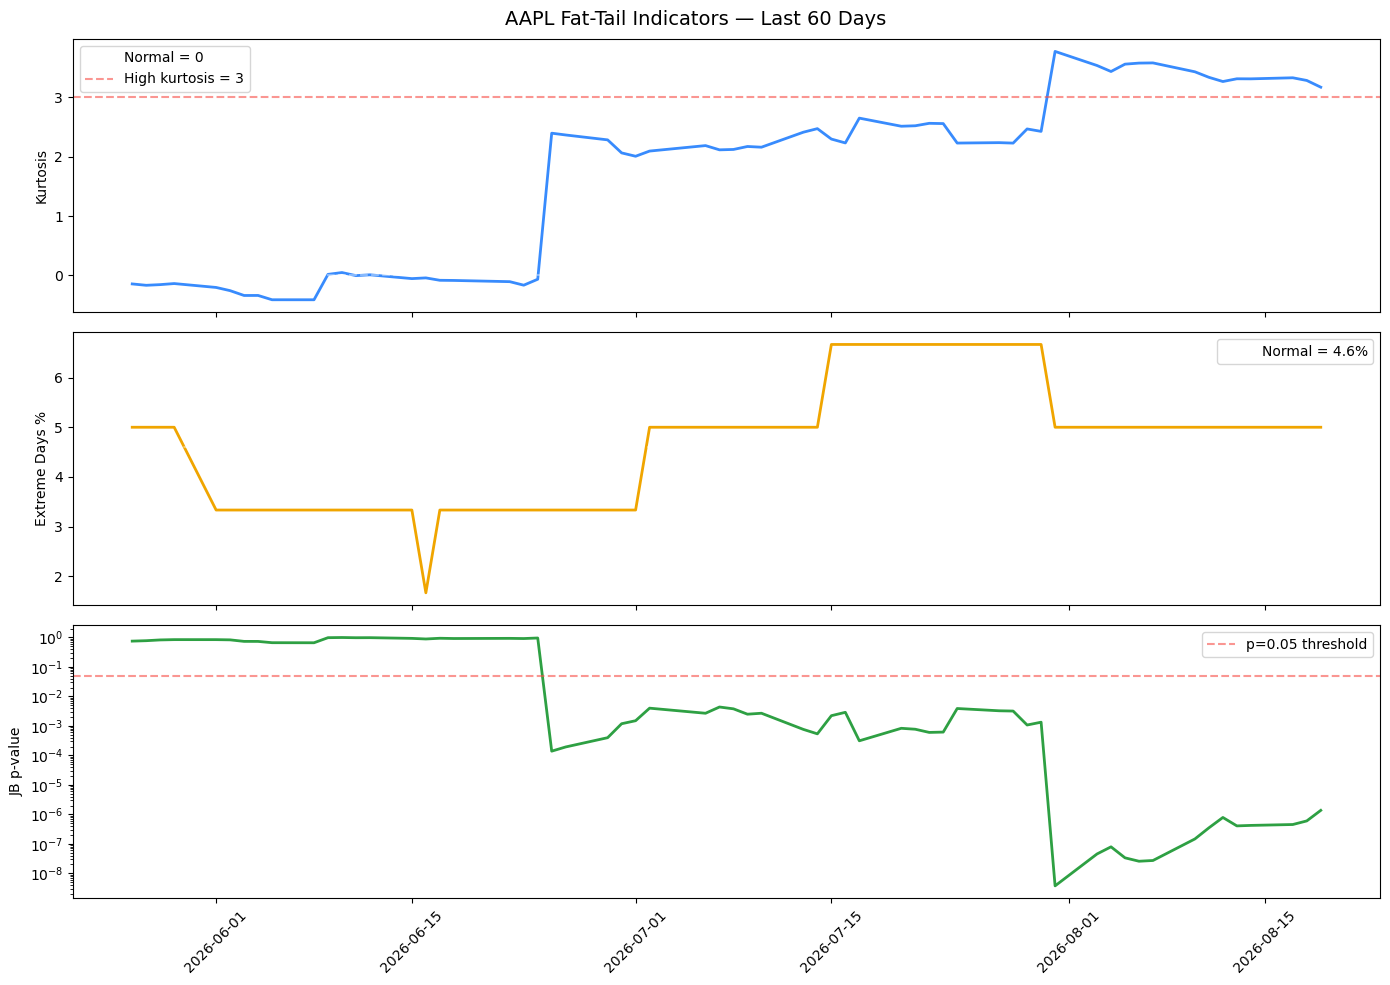

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("AAPL Fat-Tail Indicators — Last 60 Days", fontsize=14)

# Chart 1 — rolling kurtosis
axes[0].plot(last_60["Date"], last_60["roll_kurtosis"], color="#388bfd", linewidth=2)
axes[0].axhline(0, color="white", linestyle="--", alpha=0.4, label="Normal = 0")
axes[0].axhline(3, color="#f85149", linestyle="--", alpha=0.6, label="High kurtosis = 3")
axes[0].set_ylabel("Kurtosis")
axes[0].legend()

# Chart 2 — extreme return frequency
axes[1].plot(last_60["Date"], last_60["extreme_freq"] * 100, color="#f0a500", linewidth=2)
axes[1].axhline(4.6, color="white", linestyle="--", alpha=0.4, label="Normal = 4.6%")
axes[1].set_ylabel("Extreme Days %")
axes[1].legend()

# Chart 3 — JB p-value (log scale so tiny values are visible)
axes[2].plot(last_60["Date"], last_60["jb_pvalue"], color="#2ea043", linewidth=2)
axes[2].axhline(0.05, color="#f85149", linestyle="--", alpha=0.6, label="p=0.05 threshold")
axes[2].set_ylabel("JB p-value")
axes[2].set_yscale("log")
axes[2].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

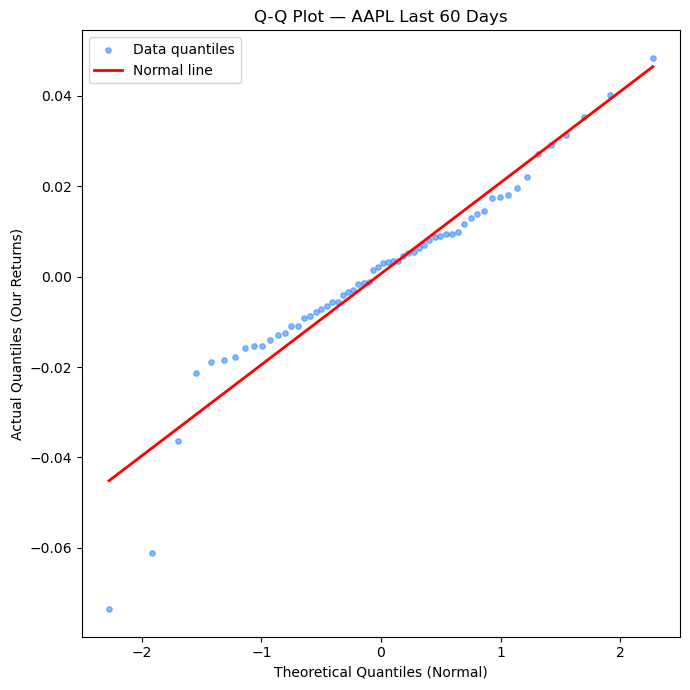

In [11]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

returns_60 = last_60["return"].dropna()

fig, ax = plt.subplots(figsize=(7, 7))

(osm, osr), (slope, intercept, _) = stats.probplot(returns_60, dist="norm")
ax.scatter(osm, osr, color="#388bfd", alpha=0.6, s=15, label="Data quantiles")
ax.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=2, label="Normal line")

ax.set_title("Q-Q Plot — AAPL Last 60 Days")
ax.set_xlabel("Theoretical Quantiles (Normal)")
ax.set_ylabel("Actual Quantiles (Our Returns)")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Step 6 — label each window as fat-tail regime or normal
df_roll["fat_tail"] = (
    (df_roll["roll_kurtosis"] > 1) &        # fatter tails than normal
    (df_roll["extreme_freq"] > 0.05) &      # more than 5% extreme days
    (df_roll["jb_pvalue"] < 0.05)           # not normally distributed
)

normal_days   = (df_roll["fat_tail"] == False).sum()
fat_tail_days = (df_roll["fat_tail"] == True).sum()

print(f"Normal regime days:   {normal_days}")
print(f"Fat-tail regime days: {fat_tail_days}")
print(f"% of time in fat-tail regime: {fat_tail_days / len(df_roll):.1%}")

df_roll[["Date", "roll_kurtosis", "extreme_freq", "jb_pvalue", "fat_tail"]].tail(10)

Normal regime days:   344
Fat-tail regime days: 172
% of time in fat-tail regime: 33.3%


,Date,roll_kurtosis,extreme_freq,jb_pvalue,fat_tail
506,2026-08-06,3.575863,0.05,2.578744e-08,False
507,2026-08-07,3.578976,0.05,2.732319e-08,False
508,2026-08-10,3.429293,0.05,1.470324e-07,False
509,2026-08-11,3.336464,0.05,3.498053e-07,False
510,2026-08-12,3.265641,0.05,7.860988e-07,False
511,2026-08-13,3.311713,0.05,4.072985e-07,False
512,2026-08-14,3.310668,0.05,4.230050e-07,False
513,2026-08-17,3.328487,0.05,4.533140e-07,False
514,2026-08-18,3.283455,0.05,6.005461e-07,False
515,2026-08-19,3.170139,0.05,1.368911e-06,False


In [ ]:
##One in three days, AAPL was sitting inside a volatile 60-day period where extreme moves were more common than a normal distribution would predict

In [13]:
# get the list of dates for each regime
fat_tail_dates = df_roll[df_roll["fat_tail"] == True]["Date"].astype(str).tolist()
normal_dates   = df_roll[df_roll["fat_tail"] == False]["Date"].astype(str).tolist()

# pull options data for fat-tail regime days
fat_tail_options = con.execute("""
    SELECT
        option_type,
        impliedVolatility * 100 AS iv,
        gamma,
        vega,
        theta,
        volume,
        strike,
        DATE(snapshot_time) AS date
    FROM bronze_options_raw
    WHERE ticker = 'AAPL'
    AND impliedVolatility > 0.01
    AND impliedVolatility < 2.0
    AND HOUR(snapshot_time) BETWEEN 9 AND 18
    AND DATE(snapshot_time) IN (SELECT UNNEST(?::DATE[]))
""", [fat_tail_dates]).df()

# pull options data for normal regime days
normal_options = con.execute("""
    SELECT
        option_type,
        impliedVolatility * 100 AS iv,
        gamma,
        vega,
        theta,
        volume,
        strike,
        DATE(snapshot_time) AS date
    FROM bronze_options_raw
    WHERE ticker = 'AAPL'
    AND impliedVolatility > 0.01
    AND impliedVolatility < 2.0
    AND HOUR(snapshot_time) BETWEEN 9 AND 18
    AND DATE(snapshot_time) IN (SELECT UNNEST(?::DATE[]))
""", [normal_dates]).df()

print(f"Fat-tail options rows: {len(fat_tail_options):,}")
print(f"Normal options rows:   {len(normal_options):,}")

Fat-tail options rows: 64,870
Normal options rows:   163,462


In [14]:
# split by option type for each regime
ft_calls = fat_tail_options[fat_tail_options["option_type"] == "call"]["iv"]
ft_puts  = fat_tail_options[fat_tail_options["option_type"] == "put"]["iv"]

nm_calls = normal_options[normal_options["option_type"] == "call"]["iv"]
nm_puts  = normal_options[normal_options["option_type"] == "put"]["iv"]

print("── Fat-Tail Regime ──────────────────────")
print(f"Call IV mean: {ft_calls.mean():.2f}%   Std: {ft_calls.std():.2f}%")
print(f"Put  IV mean: {ft_puts.mean():.2f}%    Std: {ft_puts.std():.2f}%")

print()
print("── Normal Regime ────────────────────────")
print(f"Call IV mean: {nm_calls.mean():.2f}%   Std: {nm_calls.std():.2f}%")
print(f"Put  IV mean: {nm_puts.mean():.2f}%    Std: {nm_puts.std():.2f}%")

print()
print("── Difference (Fat-Tail minus Normal) ───")
print(f"Call IV: +{ft_calls.mean() - nm_calls.mean():.2f}%")
print(f"Put  IV: +{ft_puts.mean() - nm_puts.mean():.2f}%")

── Fat-Tail Regime ──────────────────────
Call IV mean: 50.18%   Std: 30.41%
Put  IV mean: 47.68%    Std: 33.07%

── Normal Regime ────────────────────────
Call IV mean: 47.07%   Std: 32.17%
Put  IV mean: 42.61%    Std: 31.92%

── Difference (Fat-Tail minus Normal) ───
Call IV: +3.10%
Put  IV: +5.07%


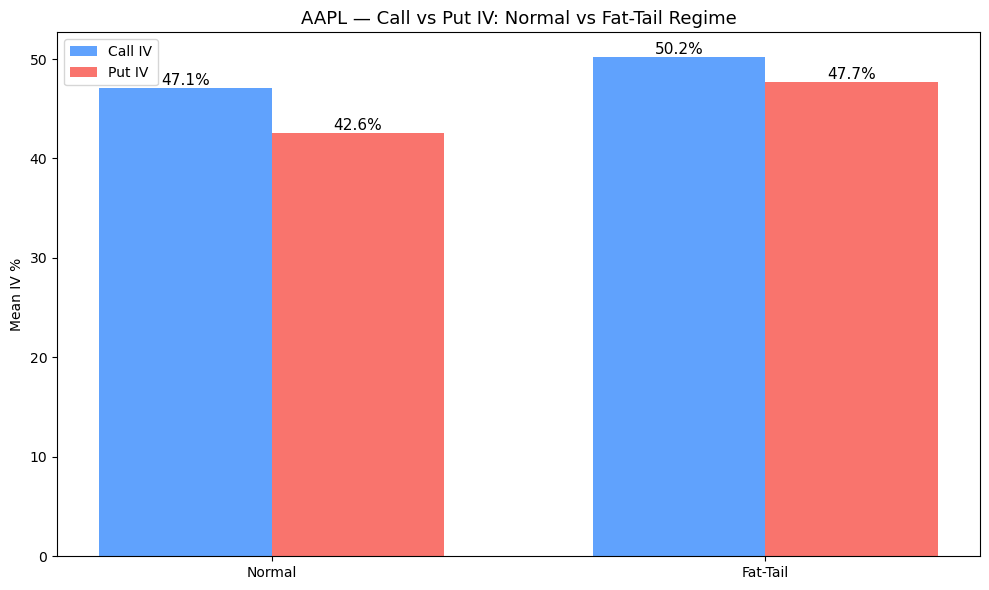

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

regimes = ["Normal", "Fat-Tail"]
call_ivs = [nm_calls.mean(), ft_calls.mean()]
put_ivs  = [nm_puts.mean(),  ft_puts.mean()]

x = np.arange(len(regimes))
width = 0.35

ax.bar(x - width/2, call_ivs, width, color="#388bfd", alpha=0.8, label="Call IV")
ax.bar(x + width/2, put_ivs,  width, color="#f85149", alpha=0.8, label="Put IV")

# add value labels on each bar
for i, (c, p) in enumerate(zip(call_ivs, put_ivs)):
    ax.text(i - width/2, c + 0.3, f"{c:.1f}%", ha="center", fontsize=11)
    ax.text(i + width/2, p + 0.3, f"{p:.1f}%", ha="center", fontsize=11)

ax.set_title("AAPL — Call vs Put IV: Normal vs Fat-Tail Regime", fontsize=13)
ax.set_ylabel("Mean IV %")
ax.set_xticks(x)
ax.set_xticklabels(regimes)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
print("── Gamma ────────────────────────────────")
print(f"Fat-tail: {fat_tail_options['gamma'].mean():.6f}")
print(f"Normal:   {normal_options['gamma'].mean():.6f}")

print()
print("── Vega ─────────────────────────────────")
print(f"Fat-tail: {fat_tail_options['vega'].mean():.4f}")
print(f"Normal:   {normal_options['vega'].mean():.4f}")

print()
print("── Theta ────────────────────────────────")
print(f"Fat-tail: {fat_tail_options['theta'].mean():.4f}")
print(f"Normal:   {normal_options['theta'].mean():.4f}")

print()
print("── Volume ───────────────────────────────")
print(f"Fat-tail: {fat_tail_options['volume'].mean():.1f}")
print(f"Normal:   {normal_options['volume'].mean():.1f}")

── Gamma ────────────────────────────────
Fat-tail: 0.003682
Normal:   0.003783

── Vega ─────────────────────────────────
Fat-tail: 0.3777
Normal:   0.3266

── Theta ────────────────────────────────
Fat-tail: -0.0810
Normal:   -0.0616

── Volume ───────────────────────────────
Fat-tail: 588.4
Normal:   461.1
